<a href="https://colab.research.google.com/github/Ly0n/substation-seg/blob/main/subdetect_sentinel2_stac.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
!pip install planetary_computer odc-stac xarray pystac-client torchgeo rioxarray

In [13]:
import argparse
import numpy as np
import torch
import random
import os
from torchgeo.models import ResNet18_Weights,ResNet50_Weights, ViTSmall16_Weights

class dotdict(dict):
    """dot.notation access to dictionary attributes"""
    __getattr__ = dict.get
    __setattr__ = dict.__setitem__
    __delattr__ = dict.__delitem__

def parse_arguments(cmd_flag=False):

    if cmd_flag:
        parser = argparse.ArgumentParser(description = "Define parameters for configuring the models and training pipeline. This includes loss function, model_directiory, model_size, normalizing strategy etc")
        parser.add_argument("-dd","--data_dir", default = "/scratch/kj1447/gracelab/dataset", help="Data Directory")
        parser.add_argument("-d","--dataset", default = "substation", help="Which dataset to use - substation or phileo. If you use phileo, set task flag accordingly.")
        parser.add_argument("-m","--model_dir", help="Model Directory for Saving Checkpoints. A folder with this name would be created within the models folder")
        parser.add_argument("-l","--loss", default = "BCE", help="Can take following values - MSE, BCE, FOCAL or DICE")
        parser.add_argument("-a","--alpha", default = 0.25, type = float, help="Alpha Parameter for FOCAL Loss")
        parser.add_argument("-e","--epochs", default = 250, type = int, help="Number of epochs")
        parser.add_argument("-bs","--batch_size", default = 32, type=int, help="Batch Size")
        parser.add_argument("-w","--workers", default = 16, type=int, help="Number of Workers")
        parser.add_argument("-tr", "--train_ratio", default = 0.8, type = float, help = "Train-Validation Ratio")
        parser.add_argument("-lr", "--learning_rate", default = 1e-3, type = float, help = "Learning Rate")
        parser.add_argument("-s","--seed", default = 42, type = int, help="Seed for reproducibility")
        parser.add_argument("-r", "--resume_training",  action="store_true",  help = "Resume training from checkpoint")
        parser.add_argument("-cp", "--checkpoint", help = "Path for the checkpoint. This needs to be set if resume_training is True")
        parser.add_argument("-lkb", "--lookback", default = 20, type = int, help = "Number of epochs to wait before early stopping")
        parser.add_argument("-se", "--starting_epoch", default = 0, type = int, help = "Epoch number for restarting training")
        parser.add_argument("-ui", "--upsampled_image_size", default = 256, type = int, help = "Size of Upsampled Image")
        parser.add_argument("-um", "--upsampled_mask_size", default = 256, type = int, help = "Size of Upsampled Mask")
        parser.add_argument("-mt","--model_type", default='vanilla_unet', help='type of models include vanilla_unet, mi_unet, modified_unet, swin, vit_torchgeo and vit_imagenet')
        parser.add_argument("-ic","--in_channels", default=13, type = int, help='number of input channels to use')
        parser.add_argument("-ut","--use_timepoints", action="store_true", help='boolean flag to decide whether or not to use multiple timepoints? (true/false)')
        parser.add_argument("-p", "--pretrained",  action="store_true",  help = "boolean flag to decide whether to use Pretrained Model")
        parser.add_argument("-nt","--normalizing_type", default='percentile', help='Type of Normalization Used-  percentile,constant or zscore. For percentile, we use 1st and 99th percentile to perform linear scaling.')
        parser.add_argument("-nf","--normalizing_factor", default=4000, type = int, help='Normalizing Factor for images. This is used if normalizing_type is constant')
        parser.add_argument("-lu", "--learned_upsampling",  action="store_true",  help = "Flag to train Deconvolution Layers on top of Swin Transformer")
        parser.add_argument("-ena", "--exp_name", help = "Experiment Name for wanDB tracking")
        parser.add_argument("-enu", "--exp_number",  default=1,  help = "Experiment Number with same setting for wanDB tracking")
        parser.add_argument("-t", "--task",  default='building',  help = "Used to define different segmentation task for the PhilEO dataset. Values = building, roads or lc")
        parser.add_argument("-vs","--vit_size", default = 'base', help='vit architecture')
        parser.add_argument("-tom","--type_of_model", default='classification', help='Defines if the model performs a classification task or a regression task')
        parser.add_argument('-ta','--timepoint_aggregation', default = 'concat', help='Defines how to use multiple timepoint. Either concat or take a median. For single image input, it takes values - first or random')

        args = vars(parser.parse_args())

    else:
        # if cmdline arguments can't be passed. eg. when running through a jupyter notebook
        args = {}
        args['data_dir']= "/scratch/kj1447/gracelab/dataset"
        args['dataset']='substation'
        args['model_dir'] = '/scratch/kj1447/gracelab/models/SWIN_FPN_low_LR'
        args['loss'] = "BCE"
        args['alpha'] = 0.25
        args['epochs'] = 250
        args['batch_size'] = 16
        args['workers'] = 16
        args['train_ratio'] = 0.8
        args['learning_rate'] = 1e-4
        args['seed'] = 42
        args['resume_training'] = False
        args['checkpoint']=None
        args['lookback'] = 10
        args['starting_epoch'] = 0
        args['upsampled_image_size']=256
        args['upsampled_mask_size']=256
        args['model_type']='swin'
        args['in_channels'] = 3
        args['use_timepoints']=True
        args['pretrained']=True
        args['normalizing_type'] = "constant"
        args['normalizing_factor'] = 4000
        args['learned_upsampling']=True
        args['exp_name']="SWIN_MI"
        args['exp_number']=1
        args['vit_size'] ='base'
        args['task'] = 'building'
        args['type_of_model']='classification'
        args['timepoint_aggregation']='concat'
    args = dotdict(args)
    args = sanity_checks(args)
    print(args)
    return args

def sanity_checks(args):

    #Defining Pretrained Weights
    if args.model_type == 'vanilla_unet' or args.model_type =='modified_unet' or args.model_type == 'mi_unet' or args.model_type == 'mi_unet_output_space':
        if args.pretrained:
            if args.in_channels == 3:
                args.pretrained_weights = ResNet50_Weights.SENTINEL2_RGB_MOCO
            elif args.in_channels == 13:
                args.pretrained_weights = ResNet50_Weights.SENTINEL2_ALL_MOCO
            else:
                assert False
        else:
            args.pretrained_weights = None

    elif args.model_type=='swin' or args.model_type=='swin_output_space' :
        if args.in_channels == 3:
            if args.use_timepoints:
                args.pretrained_weights = "Sentinel2_SwinB_MI_RGB"
            else:
                args.pretrained_weights = "Sentinel2_SwinB_SI_RGB"
        else:
            args.pretrained_weights = "Sentinel2_SwinB_MI_MS"
            # raise Exception("SWIN Backbone not Implemented with Multi Channel input")

    elif args.model_type == 'vit_torchgeo':
        args.pretrained_weights = ViTSmall16_Weights.SENTINEL2_ALL_DINO
        args.embedding_size = 384

    elif args.model_type == 'vit_imagenet' or args.model_type == 'vit_imagenet_output_space' :
        if args.vit_size=='small':
            args.pretrained_weights='vit_small_patch16_224'
            args.embedding_size = 384
        elif args.vit_size == 'base':
            args.pretrained_weights= 'vit_base_patch16_224'
            args.embedding_size = 768
        elif args.vit_size == 'large':
            args.pretrained_weights= 'vit_large_patch16_224'
            args.embedding_size = 1024

    if args.pretrained:
        assert args.pretrained_weights is not None

    if args.resume_training:
        assert args.checkpoint is not None
        assert os.path.exists(args.checkpoint)

    # Normalizing Schemes
    if args.normalizing_type == 'percentile':
        args.normalizing_factor = np.array([[1187.   , 1836.   ,  649.   ],
                                            [ 878.   , 1931.085, 1053.085],
                                            [ 749.   , 1982.51 , 1233.51 ],
                                            [ 478.   , 2287.17 , 1809.17 ],
                                            [ 744.   , 2317.   , 1573.   ],
                                            [1248.   , 3195.   , 1947.   ],
                                            [1389.   , 3853.   , 2464.   ],
                                            [1205.83 , 3840.335, 2634.505],
                                            [1455.   , 4186.   , 2731.   ],
                                            [ 462.   , 1084.   ,  622.   ],
                                            [  10.   ,   16.   ,    6.   ],
                                            [1053.   , 3444.68 , 2391.68 ],
                                            [ 501.   , 2715.   , 2214.   ]])

    # if args.model_type == 'vit_imagenet':
        # if args.normalizing_type !='zscore':
        #     raise Warning("ImageNet model requires zscores as input")
        #     args.normalizing_type = 'zscore'
        #     args.means = np.array([1431, 1233, 1209, 1192, 1448, 2238, 2609, 2537, 2828, 884, 20, 2226, 1537]).reshape(-1, 1, 1)
        #     args.stds = np.array([157, 254, 290, 420, 363, 457, 575, 606, 630, 156, 3, 554, 523]).reshape(-1, 1, 1)

    if args.normalizing_type == 'zscore':
        args.means = np.array([1431, 1233, 1209, 1192, 1448, 2238, 2609, 2537, 2828, 884, 20, 2226, 1537]).reshape(-1, 1, 1)
        args.stds = np.array([157, 254, 290, 420, 363, 457, 575, 606, 630, 156, 3, 554, 523]).reshape(-1, 1, 1)

    # Input Channel Checks
    if args.model_type=='swin':
        if args.in_channels!=3:
            if args.in_channels !=9:
                raise Warning("Swin Model can take only 9 channles for MS input. Setting input channels to 9.")
                args.in_channels = 9
    elif args.model_type == 'vit_imagenet':
        if args.in_channels != 3:
            raise Warning("Vit Imagenet Model can take only 3 channles. Setting input channels to 3.")
            args.in_channels = 3
    elif args.model_type == 'vit_torchgeo':
        if args.in_channels != 13:
            raise Warning("Vit Torchgeo Model can take only 13 channles. Setting input channels to 13.")
            args.in_channels = 13

    if args.model_type =='swin' or args.model_type == 'swin_output_space':
        args.mask_2d=True
    else:
        args.mask_2d=False


    ## Loss function
    if args.type_of_model == 'regression':
        if args.loss != 'MSE':
            raise Warning("Set loss to MSE for regression task")

    return args


def set_seed(seed):
    #setting seed for reproducibility
    torch.manual_seed(seed)
    random.seed(seed)



In [14]:
args = parse_arguments(False)

args.batch_size = 1
args.worker = 1
args.in_channels = 9
args.upsampled_image_size=224
args.upsampled_mask_size=224
args.normalizing_type= 'zscore'
args.model_type='swin'
args.vit_size='base'
args.use_timepoints=False
args.resume_training=False
args.checkpoint = './weights/swin_single_image_multi_spectral.pth'
args = sanity_checks(args)

{'data_dir': '/scratch/kj1447/gracelab/dataset', 'dataset': 'substation', 'model_dir': '/scratch/kj1447/gracelab/models/SWIN_FPN_low_LR', 'loss': 'BCE', 'alpha': 0.25, 'epochs': 250, 'batch_size': 16, 'workers': 16, 'train_ratio': 0.8, 'learning_rate': 0.0001, 'seed': 42, 'resume_training': False, 'checkpoint': None, 'lookback': 10, 'starting_epoch': 0, 'upsampled_image_size': 256, 'upsampled_mask_size': 256, 'model_type': 'swin', 'in_channels': 3, 'use_timepoints': True, 'pretrained': True, 'normalizing_type': 'constant', 'normalizing_factor': 4000, 'learned_upsampling': True, 'exp_name': 'SWIN_MI', 'exp_number': 1, 'vit_size': 'base', 'task': 'building', 'type_of_model': 'classification', 'timepoint_aggregation': 'concat', 'pretrained_weights': 'Sentinel2_SwinB_MI_RGB', 'mask_2d': True}


In [15]:
!wget https://huggingface.co/datasets/neurograce/SubstationDataset/resolve/main/models/swin_single_image_multi_spectral.pth -P ./weights/

--2025-04-30 14:22:04--  https://huggingface.co/datasets/neurograce/SubstationDataset/resolve/main/models/swin_single_image_multi_spectral.pth
Resolving huggingface.co (huggingface.co)... 13.35.202.121, 13.35.202.34, 13.35.202.97, ...
Connecting to huggingface.co (huggingface.co)|13.35.202.121|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://cdn-lfs-us-1.hf.co/repos/93/43/9343d6c0233b3fc42098d9c02625ffeb75741f5d0c84de79f54a3998536a95b9/2493999cd59c3b41d5c5848524cb72b2fc0947b2a0772733c03a772c4340eb81?response-content-disposition=inline%3B+filename*%3DUTF-8%27%27swin_single_image_multi_spectral.pth%3B+filename%3D%22swin_single_image_multi_spectral.pth%22%3B&Expires=1746026524&Policy=eyJTdGF0ZW1lbnQiOlt7IkNvbmRpdGlvbiI6eyJEYXRlTGVzc1RoYW4iOnsiQVdTOkVwb2NoVGltZSI6MTc0NjAyNjUyNH19LCJSZXNvdXJjZSI6Imh0dHBzOi8vY2RuLWxmcy11cy0xLmhmLmNvL3JlcG9zLzkzLzQzLzkzNDNkNmMwMjMzYjNmYzQyMDk4ZDljMDI2MjVmZmViNzU3NDFmNWQwYzg0ZGU3OWY1NGEzOTk4NTM2YTk1YjkvMjQ5Mzk5OWNkNTljM2I0

In [16]:
#DATALOADER
import torchvision.transforms as transforms
geo_transform = None
color_transform = None

image_resize = transforms.Compose([transforms.Resize(args.upsampled_image_size,transforms.InterpolationMode.BICUBIC, antialias=True)])

In [17]:
!git clone https://github.com/allenai/satlaspretrain_models.git
!pip install satlaspretrain_models

fatal: destination path 'satlaspretrain_models' already exists and is not an empty directory.


In [18]:
import segmentation_models_pytorch as smp
from torchvision.models._api import WeightsEnum
from torch import nn
import torch
import satlaspretrain_models
import torchgeo
import timm
import segmentation_models_pytorch as smp
from torchvision.ops import sigmoid_focal_loss

class SwinWithUpSample(nn.Module):

    def __init__(self, fpn_model, args):
        super(SwinWithUpSample, self).__init__()
        self.args = args
        self.mid_channels = 128

        if self.args.type_of_model == 'classification':
            self.num_outputs=2
        else:
            self.num_outputs = 1

        self.fpn_model = fpn_model
        self.upsampler = nn.Sequential(
            nn.Conv2d(self.mid_channels, self.mid_channels, 3, padding=1),
            nn.ReLU(inplace=True),

            nn.ConvTranspose2d(self.mid_channels, self.mid_channels // 2, kernel_size=2, stride=2),
            nn.Conv2d(self.mid_channels // 2, self.mid_channels // 2, kernel_size=3, padding=1),
            #nn.BatchNorm2d(self.mid_channels // 2),
            nn.ReLU(inplace=True),

            nn.ConvTranspose2d(self.mid_channels // 2, self.mid_channels // 4, kernel_size=2, stride=2),
            nn.Conv2d(self.mid_channels // 4, self.mid_channels // 4, kernel_size=3, padding=1),
            #nn.BatchNorm2d(self.mid_channels // 4),
            nn.ReLU(inplace=True),

            torch.nn.Conv2d(self.mid_channels//4, self.num_outputs, 3, padding=1),
        )

        def classification_loss_func(logits, targets):
            targets = targets.argmax(dim=1)
            return torch.nn.functional.cross_entropy(logits, targets, reduction='none')[:, None, :, :]

        def regression_loss_func(logits, targets):
            return torch.nn.functional.mse_loss(logits, targets, reduction='none')

        if self.args.type_of_model == 'classification':
            self.loss_func = classification_loss_func
        else:
            self.loss_func = regression_loss_func


    def forward(self, image, target=None):
        loss=None
        feature = self.fpn_model(image)
        raw_outputs = self.upsampler(feature[0])

        if self.args.type_of_model == 'classification':
            outputs = torch.nn.functional.softmax(raw_outputs, dim=1)
        else:
            outputs = raw_outputs

        if target is not None:
            loss = self.loss_func(raw_outputs, target)
            loss = loss.mean()
        return outputs, loss


class SwinWithUpSample_output_space(nn.Module):

    def __init__(self, fpn_model, args):
        super(SwinWithUpSample_output_space, self).__init__()
        self.args = args
        self.mid_channels = 128

        if self.args.type_of_model == 'classification':
            self.num_outputs=2
        else:
            self.num_outputs = 1

        self.fpn_model = fpn_model
        self.upsampler = nn.Sequential(
            nn.Conv2d(self.mid_channels, self.mid_channels, 3, padding=1),
            nn.ReLU(inplace=True),

            nn.ConvTranspose2d(self.mid_channels, self.mid_channels // 2, kernel_size=2, stride=2),
            nn.Conv2d(self.mid_channels // 2, self.mid_channels // 2, kernel_size=3, padding=1),
            #nn.BatchNorm2d(self.mid_channels // 2),
            nn.ReLU(inplace=True),

            nn.ConvTranspose2d(self.mid_channels // 2, self.mid_channels // 4, kernel_size=2, stride=2),
            nn.Conv2d(self.mid_channels // 4, self.mid_channels // 4, kernel_size=3, padding=1),
            #nn.BatchNorm2d(self.mid_channels // 4),
            nn.ReLU(inplace=True),

            torch.nn.Conv2d(self.mid_channels//4, self.num_outputs, 3, padding=1),
        )

        def classification_loss_func(logits, targets):
            targets = targets.argmax(dim=1)
            return torch.nn.functional.cross_entropy(logits, targets, reduction='none')[:, None, :, :]

        def regression_loss_func(logits, targets):
            return torch.nn.functional.mse_loss(logits, targets, reduction='none')

        if self.args.type_of_model == 'classification':
            self.loss_func = classification_loss_func
        else:
            self.loss_func = regression_loss_func


    def forward(self, image, target=None):
        loss=None
        bs, cxt, h, w = image.shape
        num_timepoints = cxt// self.args.in_channels
        image = torch.reshape(image, (-1, self.args.in_channels, h,w))
        feature = self.fpn_model(image)
        raw_outputs = self.upsampler(feature[0])
        raw_outputs = torch.reshape(raw_outputs, (bs, num_timepoints, raw_outputs.shape[1], raw_outputs.shape[2],  raw_outputs.shape[3]))
        raw_outputs = torch.median(raw_outputs, dim = 1)[0] #bs, c, h, w

        if self.args.type_of_model == 'classification':
            outputs = torch.nn.functional.softmax(raw_outputs, dim=1)
        else:
            outputs = raw_outputs

        if target is not None:
            loss = self.loss_func(raw_outputs, target)
            loss = loss.mean()
        return outputs, loss

class MiUnet(nn.Module):
    def __init__(self, unet, loss_fn, args):
        super(MiUnet,self).__init__()
        self.encoder = unet.encoder
        self.decoder = unet.decoder
        self.segmentation_head = unet.segmentation_head
        # self.num_images_per_timepoint = 3
        self.loss_fn = loss_fn
        self.args = args

    def forward(self, image, target):
        bs, cxi, w, h = image.shape
        num_timepoints = cxi// self.args.in_channels

        image = torch.reshape(image, (bs, num_timepoints, -1, w,h))
        bs, t, c, w, h = image.shape
        image = torch.reshape(image, (-1,c,w,h))
        temp = self.encoder(image)
        features = []
        for i in range(len(temp)):
            bsxi, c, w, h = temp[i].shape
            x=torch.reshape(temp[i],(-1,num_timepoints,c, w, h)).permute(1,0,2,3,4) #t,bs,c,w,h
            x = torch.amax(x, 0) #or use this -> x = torch.maximum(torch.maximum(torch.maximum(x[0],x[1]),x[2]), x[3])
            # x = torch.mean(x, 0) #average pooling of multiple timepoints
            features.append(x)
        decoder_output = self.decoder(*features)
        raw_outputs = self.segmentation_head(decoder_output)
        if self.args.loss == 'FOCAL':
            loss = self.loss_fn(raw_outputs, target, alpha = args.alpha, reduction = 'mean')
        else :
            loss = self.loss_fn(raw_outputs, target)

        if self.args.type_of_model == 'classification':
            outputs = torch.nn.functional.sigmoid(raw_outputs)
        else:
            outputs = raw_outputs

        return outputs, loss

class MiUnet_OutputSpace(nn.Module):
    def __init__(self, unet, loss_fn, args):
        super(MiUnet_OutputSpace,self).__init__()
        self.encoder = unet.encoder
        self.decoder = unet.decoder
        self.segmentation_head = unet.segmentation_head
        # self.num_images_per_timepoint = 3
        self.loss_fn = loss_fn
        self.args = args

    def forward(self, image, target):
        bs, cxi, w, h = image.shape
        num_timepoints = cxi// self.args.in_channels

        image = torch.reshape(image, (bs, num_timepoints, -1, w,h))
        bs, t, c, w, h = image.shape
        image = torch.reshape(image, (-1,c,w,h))
        temp = self.encoder(image)
        decoder_output = self.decoder(*temp)
        raw_outputs = self.segmentation_head(decoder_output) # bsxi,c, w,h
        bsxi, c, w, h = raw_outputs.shape
        raw_outputs = torch.reshape(raw_outputs, (-1,num_timepoints,c, w, h))#bs,t,c,w,h
        raw_outputs = torch.median(raw_outputs, dim = 1)[0] # bs, c, w, h

        if self.args.loss == 'FOCAL':
            loss = self.loss_fn(raw_outputs, target, alpha = args.alpha, reduction = 'mean')
        else :
            loss = self.loss_fn(raw_outputs, target)

        if self.args.type_of_model == 'classification':
            outputs = torch.nn.functional.sigmoid(raw_outputs)
        else:
            outputs = raw_outputs

        return outputs, loss

class ViT(nn.Module):
    def __init__(self,encoder, loss_fn, args, embedding_dim=384, use_timepoints=False):
        super().__init__()
        self.encoder = encoder
        self.embedding_dim = embedding_dim
        self.output_embed_dim = 1
        self.use_timepoints = use_timepoints
        # self.num_timepoints = 3
        num_convs=4
        num_convs_per_upscale=1
        self.loss_fn = loss_fn
        self.args = args

        self.channels = [self.embedding_dim // (2 ** i) for i in range(num_convs)]
        self.channels = [self.embedding_dim] + self.channels


        def _build_upscale_block(channels_in, channels_out):

            conv_kernel_size = 3
            conv_padding = 1
            kernel_size = 2
            stride = 2
            dilation = 1
            padding = 0
            output_padding = 0

            layers = []
            layers.append(nn.ConvTranspose2d(
                channels_in,
                channels_out,
                kernel_size=kernel_size,
                stride=stride,
                dilation=dilation,
                padding=padding,
                output_padding=output_padding,
            ))

            layers += [nn.Sequential(
                      nn.Conv2d(channels_out,
                      channels_out,
                      kernel_size=conv_kernel_size,
                      padding=conv_padding),
                      nn.BatchNorm2d(channels_out),
                      nn.Dropout(),
                      nn.ReLU()) for _ in range(num_convs_per_upscale)]

            return nn.Sequential(*layers)

        self.layers = nn.ModuleList([
            _build_upscale_block(self.channels[i], self.channels[i+1])
            for i in range(len(self.channels) - 1)
        ])

        self.conv = nn.Conv2d(self.channels[-1], self.output_embed_dim, kernel_size = 3, padding=1)

    def forward(self, image, target):
        bs, cxt, h, w = image.shape
        num_timepoints = cxt// self.args.in_channels
        if self.use_timepoints:
            image = image.reshape(bs, num_timepoints, -1, h, w)
            b, t, c, h, w = image.shape
            image = image.reshape(-1, c, h, w)

        feature = self.encoder.forward_features(image)
        if self.use_timepoints:
            temporal_features = feature.reshape(-1, num_timepoints, feature.shape[1], feature.shape[2]).permute(1,0,2,3)
            feature = torch.amax(temporal_features, dim = 0)
        feature = feature[:,1:,:].view(-1,14,14,self.embedding_dim).permute(0,3,1,2)
        for layer in self.layers:
            feature = layer(feature)
        raw_outputs = self.conv(feature)

        if self.args.loss == 'FOCAL':
            loss = self.loss_fn(raw_outputs, target, alpha = args.alpha, reduction = 'mean')
        else :
            loss = self.loss_fn(raw_outputs, target)

        if self.args.type_of_model == 'classification':
            outputs = torch.nn.functional.sigmoid(raw_outputs)
        else:
            outputs = raw_outputs

        return outputs, loss

class ViT_ouput_space(nn.Module):
    def __init__(self,encoder, loss_fn, args, embedding_dim=384, use_timepoints=False):
        super(ViT_ouput_space, self).__init__()
        self.encoder = encoder
        self.embedding_dim = embedding_dim
        self.output_embed_dim = 1
        self.use_timepoints = use_timepoints
        # self.num_timepoints = 3
        num_convs=4
        num_convs_per_upscale=1
        self.loss_fn = loss_fn
        self.args = args

        self.channels = [self.embedding_dim // (2 ** i) for i in range(num_convs)]
        self.channels = [self.embedding_dim] + self.channels


        def _build_upscale_block(channels_in, channels_out):

            conv_kernel_size = 3
            conv_padding = 1
            kernel_size = 2
            stride = 2
            dilation = 1
            padding = 0
            output_padding = 0

            layers = []
            layers.append(nn.ConvTranspose2d(
                channels_in,
                channels_out,
                kernel_size=kernel_size,
                stride=stride,
                dilation=dilation,
                padding=padding,
                output_padding=output_padding,
            ))

            layers += [nn.Sequential(
                      nn.Conv2d(channels_out,
                      channels_out,
                      kernel_size=conv_kernel_size,
                      padding=conv_padding),
                      nn.BatchNorm2d(channels_out),
                      nn.Dropout(),
                      nn.ReLU()) for _ in range(num_convs_per_upscale)]

            return nn.Sequential(*layers)

        self.layers = nn.ModuleList([
            _build_upscale_block(self.channels[i], self.channels[i+1])
            for i in range(len(self.channels) - 1)
        ])

        self.conv = nn.Conv2d(self.channels[-1], self.output_embed_dim, kernel_size = 3, padding=1)

    def forward(self, image, target):
        bs, cxt, h, w = image.shape
        num_timepoints = cxt// self.args.in_channels
        if self.use_timepoints:
            image = image.reshape(bs, num_timepoints, -1, h, w)
            b, t, c, h, w = image.shape
            image = image.reshape(-1, c, h, w)

        feature = self.encoder.forward_features(image)
        feature = feature[:,1:,:].view(-1,14,14,self.embedding_dim).permute(0,3,1,2)
        for layer in self.layers:
            feature = layer(feature)
        raw_outputs = self.conv(feature)

        if self.use_timepoints:
            raw_outputs = raw_outputs.reshape(bs,t,raw_outputs.shape[1], raw_outputs.shape[2], raw_outputs.shape[3]) # bs, t, c, h, w
            raw_outputs = torch.median(raw_outputs, dim = 1)[0] #bs, c, h, w


        if self.args.loss == 'FOCAL':
            loss = self.loss_fn(raw_outputs, target, alpha = args.alpha, reduction = 'mean')
        else :
            loss = self.loss_fn(raw_outputs, target)

        if self.args.type_of_model == 'classification':
            outputs = torch.nn.functional.sigmoid(raw_outputs)
        else:
            outputs = raw_outputs

        return outputs, loss

class VanillaUnet(nn.Module):
    def __init__(self, unet, loss_fn, args):
        super().__init__()
        self.unet = unet
        self.loss_fn = loss_fn
        self.args = args

    def forward(self, image, target):
        raw_outputs = self.unet(image)
        if self.args.loss == 'FOCAL':
            loss = self.loss_fn(raw_outputs, target, alpha = args.alpha, reduction = 'mean')
        else :
            loss = self.loss_fn(raw_outputs, target)
        if self.args.type_of_model == 'classification':
            outputs = torch.nn.functional.sigmoid(raw_outputs)
        else:
            outputs = raw_outputs
        return outputs, loss


def update_layers(model):
    children = list(model.children())
    if len(children)==0:
        if isinstance(model, (torch.nn.Linear, torch.nn.Conv2d)):
            torch.nn.init.xavier_uniform_(model.weight.data)
    else:
        for c in children:
            update_layers(c)

def setup_loss_func(args):
        if args.model_type != 'swin' :
            if args.loss == 'BCE':
                criterion = nn.BCEWithLogitsLoss()
                loss_fn = lambda output, target : criterion(output, target)

            elif args.loss == 'DICE':
                criterion = smp.losses.DiceLoss(mode ='binary')
                loss_fn = lambda output, target : criterion(output, target)

            elif args.loss == 'FOCAL':
                loss_fn = sigmoid_focal_loss

            elif args.loss == 'MSE':
                criterion = nn.MSELoss()
                loss_fn = lambda output, target: criterion(output, target)
        else:
            loss_fn = None
        return loss_fn


def setup_model(args):

    loss_fn = setup_loss_func(args)


    #Setting Up Model
    if args.model_type == 'vanilla_unet':
        unet = smp.Unet(
            encoder_name="resnet50",
            encoder_weights=None,
            in_channels=args.in_channels,                  # model input channels (1 for gray-scale images, 3 for RGB, etc.)
            classes=1,                      # model output channels (number of classes in your dataset)
        #     activation = 'sigmoid'     # because using sigmoid_focal_loss
        )
        model = VanillaUnet(unet, loss_fn, args)

    elif args.model_type == 'mi_unet':
        unet = smp.Unet(
            encoder_name="resnet50",
            encoder_weights=None,
            in_channels=args.in_channels,
            classes=1,
        )
        model = MiUnet(unet, loss_fn, args)

    elif args.model_type == 'mi_unet_output_space':
        unet = smp.Unet(
            encoder_name="resnet50",
            encoder_weights=None,
            in_channels=args.in_channels,
            classes=1,
        )
        model = MiUnet_OutputSpace(unet, loss_fn, args)

    elif args.model_type == 'modified_unet':

        class ModifiedUNET(nn.Module):
            def __init__(self):
                super(ModifiedUNET, self).__init__()
                self.unet = smp.Unet(encoder_name="resnet50", encoder_weights=None, in_channels = args.in_channels, classes=1)
                self.unet.decoder.blocks[3].conv1[0] = nn.Conv2d(128, 32, kernel_size=(5, 5), stride=(1, 1), bias=False)
                self.unet.decoder.blocks[3].conv2[0] = nn.Conv2d(32, 32, kernel_size=(5, 5), stride=(1, 1), bias=False)
                self.unet.decoder.blocks[4].conv1[0] = nn.Conv2d(32, 16, kernel_size=(5, 5), stride=(1, 1), bias=False)
                self.unet.decoder.blocks[4].conv2[0] = nn.Conv2d(16, 16, kernel_size=(5, 5), stride=(1, 1), bias=False)
                self.unet.segmentation_head[0] = nn.Conv2d(16, 1, kernel_size=(5,5), stride = (1,1)) #squeeze output

            def forward(self, x):
                x = self.unet(x)
                return x

        model = ModifiedUNET()

    elif args.model_type == 'swin':
        if args.learned_upsampling:
            #MODEL with learned upsampling
            weights_manager = satlaspretrain_models.Weights()
            fpn_model = weights_manager.get_pretrained_model(args.pretrained_weights, fpn = True,)
            model = SwinWithUpSample(fpn_model,args)
        else:
            weights_manager = satlaspretrain_models.Weights()
            model = weights_manager.get_pretrained_model(args.pretrained_weights, fpn = True, head = satlaspretrain_models.Head.BINSEGMENT, num_categories = 2)

    elif args.model_type == 'swin_output_space':
        if args.learned_upsampling:
            #MODEL with learned upsampling
            weights_manager = satlaspretrain_models.Weights()
            fpn_model = weights_manager.get_pretrained_model(args.pretrained_weights, fpn = True,)
            model = SwinWithUpSample_output_space(fpn_model,args)
        else:
            weights_manager = satlaspretrain_models.Weights()
            model = weights_manager.get_pretrained_model(args.pretrained_weights, fpn = True, head = satlaspretrain_models.Head.BINSEGMENT, num_categories = 2)

    elif args.model_type == 'vit_torchgeo':
        vit_encoder = torchgeo.models.vit_small_patch16_224(args.pretrained_weights)
        model = ViT(vit_encoder,  loss_fn, args, args.embedding_size, use_timepoints = args.use_timepoints)

    elif args.model_type == 'vit_imagenet':
        vit_encoder = timm.create_model(args.pretrained_weights, pretrained = args.pretrained)
        model = ViT(vit_encoder, loss_fn, args, args.embedding_size, use_timepoints = args.use_timepoints)

    elif args.model_type == 'vit_imagenet_output_space':
        vit_encoder = timm.create_model(args.pretrained_weights, pretrained = args.pretrained)
        model = ViT_ouput_space(vit_encoder, loss_fn, args, args.embedding_size, use_timepoints = args.use_timepoints)

    else:
        raise Exception("Incorrect Model Selected")

    #Loading Pretrained Weights
    if args.pretrained:
        #assert pretrained_weights is not None
        if isinstance(args.pretrained_weights, WeightsEnum):
            state_dict = args.pretrained_weights.get_state_dict(progress=True)
            if args.model_type == 'modified_unet':
                model.unet.encoder.load_state_dict(state_dict)
            elif args.model_type == 'vanilla_unet':
                model.unet.encoder.load_state_dict(state_dict)
            elif args.model_type == 'mi_unet':
                model.encoder.load_state_dict(state_dict)
            elif args.model_type == 'mi_unet_output_space':
                model.encoder.load_state_dict(state_dict)
            else:
                raise Exception("Incorrect combination of weights and model")
    else:
        if args.model_type =='swin':
            #Randomly initializing weights for SWIN model
            update_layers(model)

    #Loading checkpoints
    if args.resume_training:
        if torch.cuda.is_available():
            device = torch.device("cuda:0")
        else:
            device = torch.device("cpu")
        model = model.to(device)
        checkpoint = torch.load(args.checkpoint,  map_location=device)
        model.load_state_dict(checkpoint)

    return model


In [19]:
import torch

if torch.cuda.is_available():
    device = torch.device("cuda:0")
    print("Use GPU")
else:
    device = torch.device("cpu")
    print("Use CPU")

checkpoint = torch.load("./weights/swin_single_image_multi_spectral.pth",map_location=device)

torch.manual_seed(args.seed)
model = setup_model(args).to(device)

Use GPU


In [20]:
#model.load_state_dict(checkpoint['model_state_dict'])

# Set the model to evaluation mode
model.eval()








SwinWithUpSample(
  (fpn_model): Model(
    (backbone): AggregationBackbone(
      (backbone): SwinBackbone(
        (backbone): SwinTransformer(
          (features): Sequential(
            (0): Sequential(
              (0): Conv2d(9, 128, kernel_size=(4, 4), stride=(4, 4))
              (1): Permute()
              (2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
            )
            (1): Sequential(
              (0): SwinTransformerBlockV2(
                (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
                (attn): ShiftedWindowAttentionV2(
                  (qkv): Linear(in_features=128, out_features=384, bias=True)
                  (proj): Linear(in_features=128, out_features=128, bias=True)
                  (cpb_mlp): Sequential(
                    (0): Linear(in_features=2, out_features=512, bias=True)
                    (1): ReLU(inplace=True)
                    (2): Linear(in_features=512, out_features=4, bias=False)
          

In [21]:
import torch
import numpy as np
import xarray as xr
from pystac_client import Client
from odc.stac import stac_load
from shapely.geometry import box
import geopandas as gpd
from IPython.display import display

km2deg = 1.0 / 111
## Substation in Kenya: -1.7741969, 36.8318356
lat_center, log_center = (-1.7741969, 36.8318356)  # Center point of a query
r = 1 * km2deg
bbox = (lat_center - r, log_center - r, lat_center + r, log_center + r)
crs = "epsg:3857"
zoom = 2**2

# ----- 2. STAC search and load -----
geometry = box(*bbox)
catalog = Client.open("https://earth-search.aws.element84.com/v1")
search = catalog.search(
    collections=["sentinel-2-l2a"],
    intersects=geometry,
    datetime="2023-01-01/2023-01-10",
    query={"eo:cloud_cover": {"lt": 10}},
    limit=10,
    max_items=1,
)

items = list(search.items())[:1]  # Select 1 image for now

selected_bands = [
    "blue", "green", "red",
    "rededge1", "rededge2", "rededge3",
    "nir", "nir08","nir09"
]

ds = stac_load(
    items,
    bands=selected_bands,
    crs=crs,
    resolution=10,#*zoom,
    chunks={},  # <-- use Dask
    groupby="solar_day",
)
ds = ds.isel(time=0)  # pick first timestamp
ds = ds[selected_bands]
display(ds)

<xarray.Dataset> Size: 3GB
Dimensions:      (y: 13804, x: 13745)
Coordinates:
  * y            (y) float64 110kB 4.446e+06 4.446e+06 ... 4.308e+06 4.308e+06
  * x            (x) float64 110kB -3.34e+05 -3.34e+05 ... -1.966e+05 -1.965e+05
    spatial_ref  int32 4B 3857
    time         datetime64[ns] 8B 2023-01-10T11:01:01.385000
Data variables:
    blue         (y, x) uint16 379MB dask.array<chunksize=(13804, 13745), meta=np.ndarray>
    green        (y, x) uint16 379MB dask.array<chunksize=(13804, 13745), meta=np.ndarray>
    red          (y, x) uint16 379MB dask.array<chunksize=(13804, 13745), meta=np.ndarray>
    rededge1     (y, x) uint16 379MB dask.array<chunksize=(13804, 13745), meta=np.ndarray>
    rededge2     (y, x) uint16 379MB dask.array<chunksize=(13804, 13745), meta=np.ndarray>
    rededge3     (y, x) uint16 379MB dask.array<chunksize=(13804, 13745), meta=np.ndarray>
    nir          (y, x) uint16 379MB dask.array<chunksize=(13804, 13745), meta=np.ndarray>
    nir08        (y, x) uint16 379MB dask.array<chunksize=(13804, 13745), meta=np.ndarray>
    nir09        (y, x) uint16 379MB dask.array<chunksize=(13804, 13745), meta=np.ndarray>

In [26]:
import numpy as np
import geopandas as gpd
from shapely.geometry import box
import rioxarray

# Step 1: Define 224×224 bbox in EPSG:4326 (10m per pixel → ~0.002016 degrees at equator)
def make_224_bbox_from_center(lat, lon, pixel_size_m=10):
    deg_per_pixel = 224 * pixel_size_m / 111320  # ~0.002016 degrees
    half = deg_per_pixel / 2
    return [lon - half, lat - half, lon + half, lat + half]

bbox_4326 = make_224_bbox_from_center(lat=log_center, lon=lat_center)

gdf = gpd.GeoDataFrame(
    {"geometry": [box(*bbox_4326)]},
    crs="EPSG:4326"
).to_crs("EPSG:3857")

# Step 3: Clip dataset (ds must be xarray.Dataset from stac_load)
ds.rio.write_crs("EPSG:3857", inplace=True)
ds_cropped = ds.rio.clip(gdf.geometry, gdf.crs)

In [27]:
def dataset_to_tensor(ds_crop):
    bands = list(ds_crop.data_vars)
    arr = np.stack([ds_crop[band].values for band in bands])  # (C, H, W)
    arr = arr.astype(np.float32) / 10000.0
    return torch.tensor(arr).unsqueeze(0)  # (1, C, 224, 224)

# Convert to tensor
chip_tensor = dataset_to_tensor(ds_cropped).to(device)

# Step 5: Run model inference
model.eval()
with torch.no_grad():
    output, _ = model(chip_tensor, target=None)
    pred = torch.argmax(output, dim=1).squeeze(0).cpu().numpy()

In [28]:
import matplotlib.pyplot as plt
import numpy as np

def show_cropped_rgb(cropped_ds, bands=["red", "green", "blue"]):
    """
    Display the cropped Sentinel-2 RGB image.

    Args:
        cropped_ds (xarray.Dataset): Cropped Sentinel-2 image (224x224).
        bands (list): List of 3 bands to use for RGB visualization.
    """
    # Extract and normalize RGB bands
    rgb = np.stack([cropped_ds[b].values for b in bands])
    rgb = np.clip(rgb.astype(np.float32) / 10000.0, 0, 1)  # Normalize reflectance
    rgb = np.transpose(rgb, (1, 2, 0))  # Shape: (H, W, 3)

    # Plot
    plt.figure(figsize=(5, 5))
    plt.imshow(rgb)
    plt.title("Cropped Sentinel-2 RGB Image")
    plt.axis("off")
    plt.show()

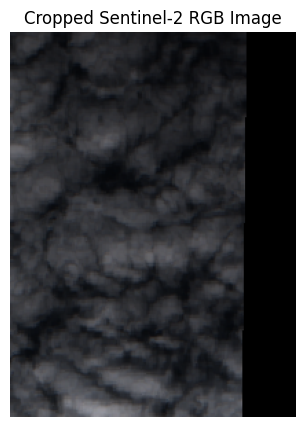

In [29]:
show_cropped_rgb(ds_cropped)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def show_cropped_r(ds_cropped, bands=["red"]):
    """
    Display the cropped Sentinel-2 RGB image.

    Args:
        cropped_ds (xarray.Dataset): Cropped Sentinel-2 image (224x224).
        bands (list): List of 3 bands to use for RGB visualization.
    """
    # Extract and normalize RGB bands
    rgb = np.stack([ds_cropped[b].values for b in bands])
    rgb = np.clip(rgb.astype(np.float32) / 10000.0, 0, 1)  # Normalize reflectance
    rgb = np.transpose(rgb, (1, 2, 0))  # Shape: (H, W, 3)

    # Plot
    plt.figure(figsize=(5, 5))
    plt.imshow(rgb)
    plt.title("Cropped Sentinel-2 RGB Image")
    plt.axis("off")
    plt.show()

In [ ]:
show_cropped_r(pred)

In [ ]:
plt.imshow(pred)
plt.show()